In [2]:
df = pd.read_csv('/kaggle/input/datasets/rsadiq/salary/Salary.csv')

In [3]:
df

,YearsExperience,Salary
0,1.1,39343
1,1.3,46205
2,1.5,37731
3,2.0,43525
4,2.2,39891
5,2.9,56642
6,3.0,60150
7,3.2,54445
8,3.2,64445
9,3.7,57189


In [4]:
X = df.iloc[:,[0]]
X

,YearsExperience
0,1.1
1,1.3
2,1.5
3,2.0
4,2.2
5,2.9
6,3.0
7,3.2
8,3.2
9,3.7


In [5]:
y = df.iloc[:,-1]
y

0      39343
1      46205
2      37731
3      43525
4      39891
5      56642
6      60150
7      54445
8      64445
9      57189
10     63218
11     55794
12     56957
13     57081
14     61111
15     67938
16     66029
17     83088
18     81363
19     93940
20     91738
21     98273
22    101302
23    113812
24    109431
25    105582
26    116969
27    112635
28    122391
29    121872
30    127345
31    126756
32    128765
33    135675
34    139465
Name: Salary, dtype: int64

In [6]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [7]:
from sklearn.preprocessing import StandardScaler
encoder = StandardScaler()
X_train_scaled = encoder.fit_transform(X_train)
X_test_scaled = encoder.transform(X_test)

In [8]:
import tensorflow
from tensorflow.keras.layers import Dense
from tensorflow.keras import Sequential

In [9]:
model = Sequential()
model.add(Dense(128,activation='relu',input_dim=1))
model.add(Dense(128,activation='relu'))
model.add(Dense(128,activation='relu'))
model.add(Dense(1,activation='linear'))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-08-12 14:07:33.138249: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [10]:
model.compile(loss='mse',optimizer='adam',metrics=['r2_score'])

In [11]:
history = model.fit(X_train_scaled,y_train,validation_split=0.2,epochs=300 )

Epoch 1/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 7892537856.0000 - r2_score: -6.5763 - val_loss: 5050160640.0000 - val_r2_score: -8.8697
Epoch 2/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - loss: 7892521984.0000 - r2_score: -6.5763 - val_loss: 5050153984.0000 - val_r2_score: -8.8697
Epoch 3/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - loss: 7892506624.0000 - r2_score: -6.5762 - val_loss: 5050146816.0000 - val_r2_score: -8.8697
Epoch 4/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - loss: 7892492800.0000 - r2_score: -6.5762 - val_loss: 5050140160.0000 - val_r2_score: -8.8697
Epoch 5/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - loss: 7892477952.0000 - r2_score: -6.5762 - val_loss: 5050132480.0000 - val_r2_score: -8.8697
Epoch 6/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - loss: 7892461568.0000 - r2_score: -6.5762 - val_loss: 5050123776.0000 - val_r2_score: -8.8697
Epoch 7/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - loss: 7892445184.0000 - r2_score: -6.5762 - val_loss: 5050114560.0000 

In [12]:
y_pred = model.predict(X_test_scaled)
from sklearn.metrics import r2_score
r2_score(y_test,y_pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step


0.4186444878578186

# r2_score without Dropout = 41.86 %

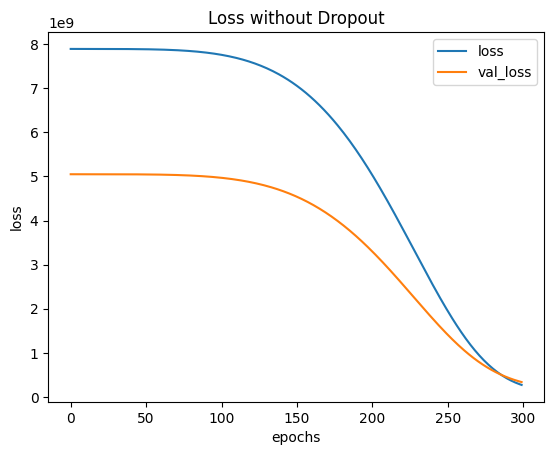

In [13]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'],label='loss')
plt.plot(history.history['val_loss'],label='val_loss')
plt.xlabel('epochs')
plt.ylabel('loss')
plt.title('Loss without Dropout')
plt.legend()

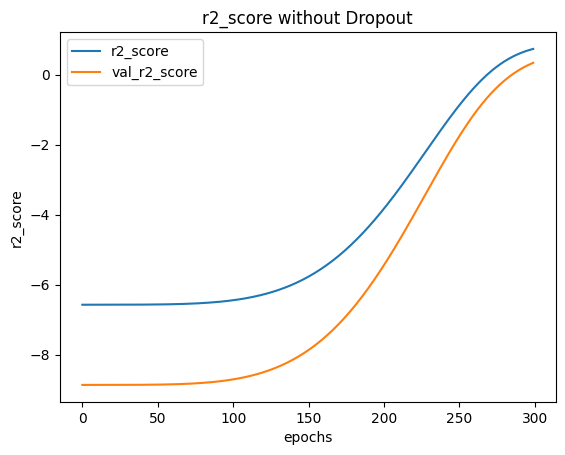

In [14]:
plt.plot(history.history['r2_score'],label='r2_score')
plt.plot(history.history['val_r2_score'],label='val_r2_score')
plt.xlabel('epochs')
plt.ylabel('r2_score')
plt.title('r2_score without Dropout')
plt.legend()

# # We here add the droupout_technique to see the Model is Overfitting or Not ?

In [15]:
from tensorflow.keras.layers import Dropout

In [16]:
model_1 = Sequential()
model_1.add(Dense(128,activation='relu',input_dim=1))
model_1.add(Dropout(0.2))
model_1.add(Dense(128,activation='relu'))
model_1.add(Dropout(0.2))
model_1.add(Dense(128,activation='relu'))
model_1.add(Dropout(0.2))
model_1.add(Dense(1,activation='linear'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [17]:
model_1.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 128)            │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,409 (130.50 KB)

 Trainable params: 33,409 (130.50 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
model_1.compile(loss='mse',optimizer='adam',metrics=['r2_score'])

In [19]:
history_with_dropout = model_1.fit(X_train_scaled,y_train,validation_split=0.2,epochs=300 )

Epoch 1/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 7892548096.0000 - r2_score: -6.5763 - val_loss: 5050166272.0000 - val_r2_score: -8.8697
Epoch 2/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - loss: 7892527104.0000 - r2_score: -6.5763 - val_loss: 5050160128.0000 - val_r2_score: -8.8697
Epoch 3/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - loss: 7892513792.0000 - r2_score: -6.5763 - val_loss: 5050153984.0000 - val_r2_score: -8.8697
Epoch 4/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - loss: 7892508160.0000 - r2_score: -6.5762 - val_loss: 5050146816.0000 - val_r2_score: -8.8697
Epoch 5/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - loss: 7892493824.0000 - r2_score: -6.5762 - val_loss: 5050139136.0000 - val_r2_score: -8.8697
Epoch 6/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - loss: 7892478976.0000 - r2_score: -6.5762 - val_loss: 5050130944.0000 - val_r2_score: -8.8697
Epoch 7/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - loss: 7892469760.0000 - r2_score: -6.5762 - val_loss: 5050122240.0000 - va

In [20]:
y_pred_with_dropout = model_1.predict(X_test_scaled)
from sklearn.metrics import r2_score
r2_score(y_test,y_pred_with_dropout)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step


0.6865432262420654

# r2_Score with Dropout = 68.65%

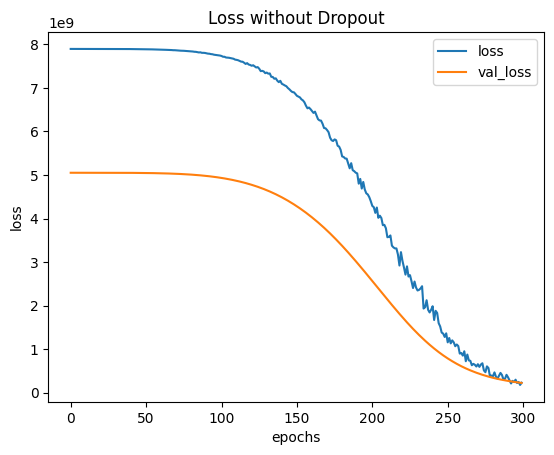

In [21]:
import matplotlib.pyplot as plt
plt.plot(history_with_dropout.history['loss'],label='loss')
plt.plot(history_with_dropout.history['val_loss'],label='val_loss')
plt.xlabel('epochs')
plt.ylabel('loss')
plt.title('Loss without Dropout')
plt.legend()

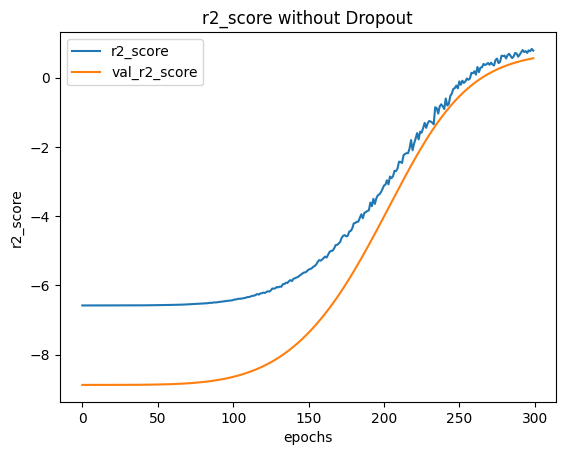

In [22]:
plt.plot(history_with_dropout.history['r2_score'],label='r2_score')
plt.plot(history_with_dropout.history['val_r2_score'],label='val_r2_score')
plt.xlabel('epochs')
plt.ylabel('r2_score')
plt.title('r2_score without Dropout')
plt.legend()